# 02 Baseline — Isolation Forest

这一份 notebook 用来完成项目的 基线：

1. 读取并清洗数据
2. 删除编号列 `Readings`
3. 对特征做标准化
4. 使用 `Isolation Forest` 进行无监督异常检测
5. 输出异常标签和异常分数
6. 做基础可视化，并定位异常窗口

这一本 notebook 的目标是回答两个问题：
- 基线模型怎么做？
- 基线模型发现了什么？


## 0. 导入库

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1500)


## 1. 读取并清洗数据

这里沿用 `01_data_check.ipynb` 中确认过的清洗逻辑：
- `Flow2` 先转字符串
- 去掉两边空格
- 把逗号改成点
- 再转成数值型

In [2]:
data_path = '../data/PWR Abnormality Dataset.csv'
df = pd.read_csv(data_path)

df['Flow2'] = df['Flow2'].astype(str).str.strip().str.replace(',', '.', regex=False)
df['Flow2'] = pd.to_numeric(df['Flow2'], errors='coerce')

print('原始数据形状：', df.shape)
print('Flow2 缺失值数量：', df['Flow2'].isna().sum())
df.head()

原始数据形状： (12267, 17)
Flow2 缺失值数量： 0


,Readings,Temperature,Pressure,Flow1,Flow2,VRR12,VRR22,VRR23,VRR33,VRS01,VRS03,VRS21,VRS31,VRS02,VRI01,VRI02,VRI03
0,1,248.852987,9.689813,4462.130014,13302.92650,19.060938,0.059119,0.050589,0.111864,0.033951,0.047812,0.232627,0.253775,0.400726,1.763223,0.003031,0.004995
1,2,269.315740,1.279532,4480.252595,13784.45225,19.062128,0.059089,0.048788,0.111340,0.034060,0.052611,0.233342,0.315067,0.128517,1.769272,0.003164,0.004999
2,3,94.320644,6.280686,4325.270376,12899.98773,19.061641,0.058145,0.048552,0.111118,0.033859,0.053999,0.233387,0.380191,0.321816,1.768585,0.003321,0.004996
3,4,271.019823,0.669886,4481.761795,13733.00610,19.062453,0.058236,0.049514,0.112658,0.034049,0.050767,0.233850,0.329846,0.132092,1.772432,0.003061,0.004998
4,5,207.876262,6.806043,4425.839490,13500.22222,19.061101,0.058378,0.049809,0.111252,0.033996,0.052669,0.233619,0.390729,0.247973,1.772356,0.003060,0.004994


## 2. 保留原始数据，删除 `Readings` 用于建模

`Readings` 是编号列，不参与建模。

这里保留两份数据：
- `df_clean`：保留原始字段，后面用来挂异常标签和分数
- `df_model`：删除 `Readings` 后真正给模型使用的特征表

In [3]:
df_clean = df.copy()
df_model = df.drop(columns=['Readings'])

print('建模数据形状：', df_model.shape)
print('\n建模列名：')
print(df_model.columns)


建模数据形状： (12267, 16)

建模列名：
Index(['Temperature', 'Pressure', 'Flow1', 'Flow2', 'VRR12', 'VRR22', 'VRR23', 'VRR33', 'VRS01', 'VRS03', 'VRS21', 'VRS31', 'VRS02', 'VRI01', 'VRI02', 'VRI03'], dtype='object')


## 3. 标准化

不同特征的量纲差异很大，例如：
- `Temperature` 是几十到几百
- `Pressure` 是个位数到十几
- `VRI03` 只有 0.0049 左右

所以要先标准化，再喂给异常检测模型。

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print('标准化后数据形状：', X_scaled.shape)
print('\n标准化后前5行：')
print(X_scaled[:5])

标准化后数据形状： (12267, 16)

标准化后前5行：
[[ 1.07893382  0.27839695  1.09565427  0.474472    0.14887539  1.13046382
   0.46888306 -0.73728938  0.51857378 -1.32248045 -0.06670638 -1.3712109
   1.75087686 -1.0301782  -1.36551064 -0.92189671]
 [ 1.39322617 -1.46366307  1.41214652  1.2882355   0.14930779  1.07598001
  -0.9690203  -1.43034304  1.36093398  0.63711464  0.46220437 -0.02484915
  -1.14435581  0.57741279 -0.12262747  0.9575598 ]
 [-1.2945655  -0.42775121 -1.29445865 -0.20648195  0.14913082 -0.65439671
  -1.15723313 -1.7230074  -0.18630969  1.20407738  0.49543531  1.40568924
   0.91157923  0.39494088  1.33908815 -0.23572976]
 [ 1.41939959 -1.58994175  1.43850315  1.20129311  0.14942579 -0.48851243
  -0.38962241  0.31275361  1.27093631 -0.11575607  0.83763278  0.29980563
  -1.10632915  1.41729241 -1.08727068  0.88120804]
 [ 0.44956248 -0.31893158  0.46187757  0.80789562  0.14893462 -0.22708244
  -0.15382106 -1.54595733  0.86371429  0.6608787   0.66690384  1.63718243
   0.12618992  1.39698202

## 4. 训练 Isolation Forest baseline

这里先使用一个最基础的配置：
- `contamination=0.05`：假设约 5% 样本为异常
- `random_state=42`：固定随机种子，保证复现

In [5]:
model = IsolationForest(contamination=0.05, random_state=42)
pred = model.fit_predict(X_scaled)
scores = model.decision_function(X_scaled)

df_clean['anomaly_label'] = pred
df_clean['anomaly_score'] = scores

print('异常检测结果统计：')
print(df_clean['anomaly_label'].value_counts())

异常检测结果统计：
anomaly_label
 1    11653
-1      614
Name: count, dtype: int64


## 5. 查看异常样本与最异常 Top 10

这里先看两部分：
- 模型判为异常的样本前几行
- 异常分数最低的 Top 10 样本

In [6]:
anomaly_df = df_clean[df_clean['anomaly_label'] == -1]
normal_df = df_clean[df_clean['anomaly_label'] == 1]

print('异常样本数量：', anomaly_df.shape)
print('正常样本数量：', normal_df.shape)

print('\n异常样本前5行：')
display(anomaly_df[['Readings', 'Temperature', 'Pressure', 'Flow1', 'Flow2', 'anomaly_label', 'anomaly_score']].head())

top10_anomaly = df_clean.sort_values(by='anomaly_score', ascending=True).head(10)
print('\n最异常的10个样本：')
display(top10_anomaly[['Readings', 'Temperature', 'Pressure', 'Flow1', 'Flow2', 'anomaly_label', 'anomaly_score']])

异常样本数量： (614, 19)
正常样本数量： (11653, 19)

异常样本前5行：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
41,42,151.522102,0.681054,4375.930133,13993.21954,-1,-0.002941
65,66,281.336909,3.523526,4490.898994,12103.25018,-1,-0.011702
74,75,274.589755,8.462758,4484.923461,13977.68461,-1,-0.013938
98,99,68.461458,3.293847,4302.368512,12035.36676,-1,-0.018971
118,119,83.352899,13.675213,4315.556930,13264.19269,-1,-0.000601



最异常的10个样本：


,Readings,Temperature,Pressure,Flow1,Flow2,anomaly_label,anomaly_score
12127,12128,287.8287,16.57636,4461.264172,14388.58200,-1,-0.104763
12124,12125,288.0672,16.58000,4484.036774,13972.37300,-1,-0.100793
12129,12130,287.5891,16.58719,4427.619761,13927.95706,-1,-0.097707
12118,12119,287.9721,16.47419,4480.147273,14956.03029,-1,-0.095733
12119,12120,287.9612,16.57160,4425.837560,14831.58653,-1,-0.094140
12121,12122,287.8750,16.57655,4409.037954,14942.36383,-1,-0.092506
12128,12129,287.6377,16.57587,4354.601835,13553.30673,-1,-0.092421
12123,12124,287.9897,16.57410,4369.390259,14016.13886,-1,-0.091411
12131,12132,287.6651,16.00017,4412.651254,13402.11830,-1,-0.091046
12116,12117,288.0049,16.57498,4322.022756,14935.33727,-1,-0.090921


## 6. 温度-压力散点图

把正常样本和异常样本画在同一张图上，直观看看异常点是否更容易出现在边界区域。

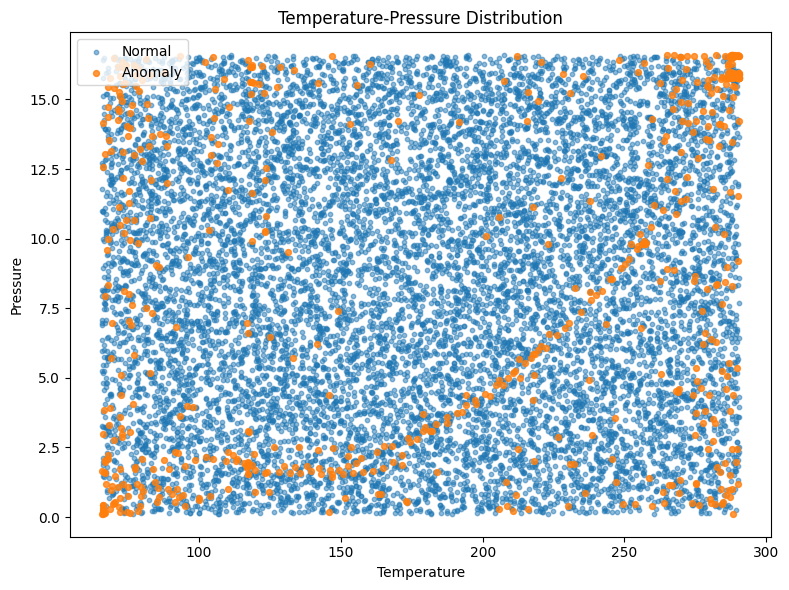

图片已保存到 ../outputs/figures/temperature_pressure_distribution.png


In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    normal_df['Temperature'],
    normal_df['Pressure'],
    s=10,
    alpha=0.5,
    label='Normal'
)

plt.scatter(
    anomaly_df['Temperature'],
    anomaly_df['Pressure'],
    s=18,
    alpha=0.8,
    label='Anomaly'
)

plt.xlabel('Temperature')
plt.ylabel('Pressure')
plt.title('Temperature-Pressure Distribution')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/temperature_pressure_distribution.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/temperature_pressure_distribution.png')

## 7. 异常分数全局图

因为 `anomaly_score` 越小越异常，所以这张图能帮助我们观察：
- 异常是随机散点
- 还是某些区间存在连续异常低谷

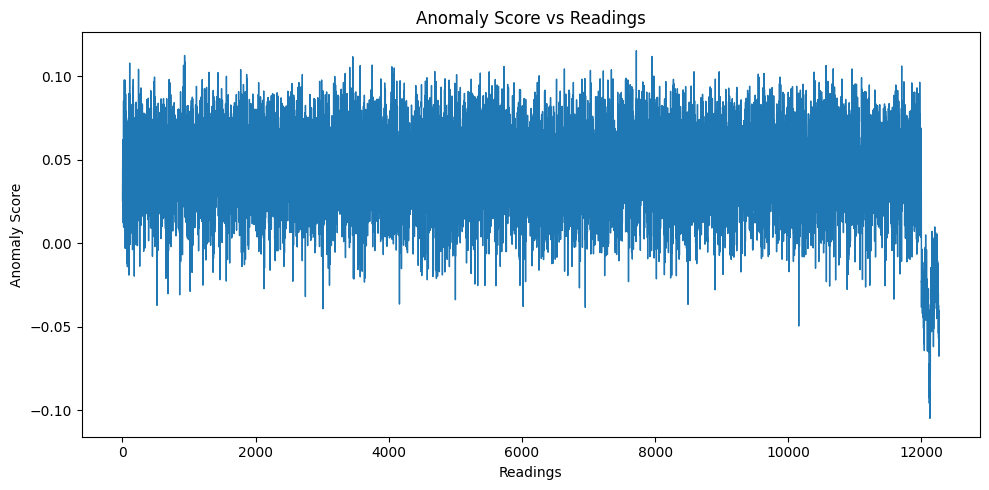

图片已保存到 ../outputs/figures/anomaly_score_all.png


In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df_clean['Readings'], df_clean['anomaly_score'], linewidth=1)
plt.xlabel('Readings')
plt.ylabel('Anomaly Score')
plt.title('Anomaly Score vs Readings')
plt.tight_layout()
plt.savefig('../outputs/figures/anomaly_score_all.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/anomaly_score_all.png')

## 8. 异常分数局部放大图

前面已经发现末端存在异常低谷，所以这里放大 `12050~12267` 区间。

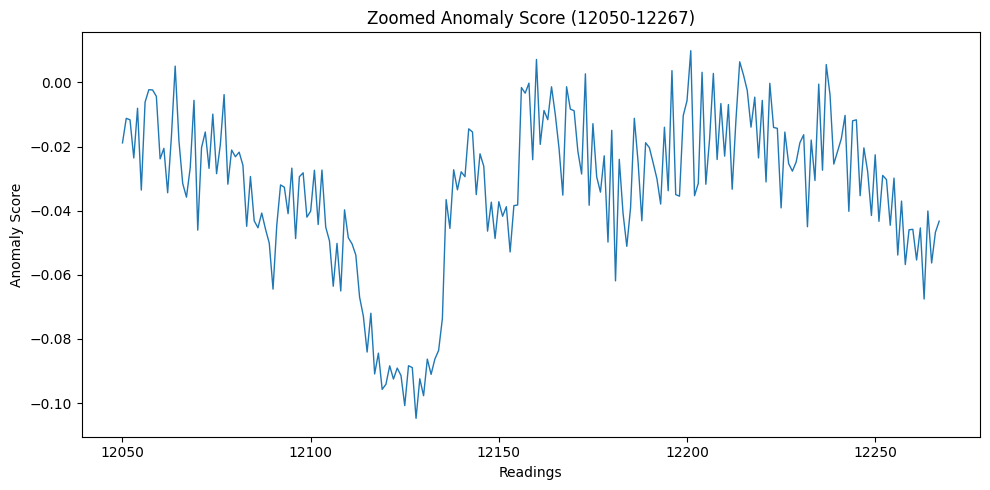

图片已保存到 ../outputs/figures/anomaly_score_zoom.png


In [9]:
zoom_df = df_clean[(df_clean['Readings'] >= 12050) & (df_clean['Readings'] <= 12267)]

plt.figure(figsize=(10, 5))
plt.plot(zoom_df['Readings'], zoom_df['anomaly_score'], linewidth=1)
plt.xlabel('Readings')
plt.ylabel('Anomaly Score')
plt.title('Zoomed Anomaly Score (12050-12267)')
plt.tight_layout()
plt.savefig('../outputs/figures/anomaly_score_zoom.png', dpi=300)
plt.show()

print('图片已保存到 ../outputs/figures/anomaly_score_zoom.png')

## 9. 保存 基线 结果表

这里把异常标签和异常分数保存下来，给后续特征分析和 `VRR12` 排查使用。

In [ ]:
save_path = '../outputs/tables/pwr_anomaly_with_scores.csv'
df_clean.to_csv(save_path, index=False)
print(f'结果表已保存到 {save_path}')

## 10. 小结

### 当前发现
- 使用 `Isolation Forest` 后，共识别出一批异常样本
- 异常并非完全随机散落，而是在末端形成明显连续低谷
- 最异常样本集中在 `Readings≈12115~12135` 附近
- 在 Temperature-Pressure 二维投影中，异常点更容易出现在边界区域

### 下一步
下一本 notebook：
**03_vrr12_investigation.ipynb**

目标是继续排查：
- `VRR12` 是否存在量级突变
- 它更像传感器异常、缩放问题，还是状态切换特征